# In this notebook, we fit different models to the collected and reduced data of EP240414a. For the GRB afterglow emission, we use the tophat_redback and gaussian_redback models, whilst, for the supernova emission, we use the arnett model. The fitting procedure is explained in Chapter 2 of the MSc thesis, but all the fitting process is performed with modifications of this notebook.

Importing the packages used in this notebook:

In [ ]:
import numpy as np
import inspect
import scipy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import redback as rd
import bilby as bb
import astropy as ast
import pandas as pd
import warnings
import extinction as ex
from astropy.table import Table, Column
from astropy import units as u
from astropy import constants as const
import astropy.io.ascii as ascii
import re
import inspect
warnings.filterwarnings('ignore')
from asym_likelihood import AsymGaussianWithUpperLimits #Custom likelihood function

In [ ]:
#Useful functions and constants used in the process of extracting the collected and reduced data:
def wavetof(wave):
    return(const.c.value/ (wave*1e-10))


CkeV = 1.602e-9 
hPlanck = 6.626e-27     
stod=(1*u.s).to(u.d).value      #From seconds to days 

#Function to change from E in keV to frequency in Hz:
def Etonu(E):
    return E*CkeV/hPlanck

#Redshift of EP240414a
z=0.401
ez=0.005


#Extracting and organizing the EP240414a processed data in the following order:
#Radio-Optical-IRUV-X-rays:
RadioTXT='/EP240414a Edu processed data/All Radio Data EP240414a.txt'
Radio = Table.read(RadioTXT, format="ascii", comment="#")
OpticalTXT='/EP240414a Edu processed data/All Optical Data EP240414a.txt'
Optical = Table.read(OpticalTXT, format="ascii", comment="#")
IRUVTXT='/EP240414a Edu processed data/All IR UV Data EP240414a.txt'
IRUV = Table.read(IRUVTXT, format="ascii", comment="#")
XrayTXT='/EP240414a Edu processed data/Xray Data EP240414a.txt'
Xray = Table.read(XrayTXT, format="ascii", comment="#")

#Now putting all the data in the same units and organizing between detections and upper limits:
RadioFreq=Radio['Frequency(GHz)']*1e9 #In Hertzs
RadioUB=np.where(Radio['Upper Limit Nature']=='Yes-3sigma')
RadioDat=np.where(Radio['Upper Limit Nature']=='No')
#3GHz
GHz3Dat = np.where((Radio['Upper Limit Nature']=='No') & (Radio['Frequency(GHz)']==3.0))[0]
#5.5GHz
GHz5Dat = np.where((Radio['Upper Limit Nature']=='No') & (Radio['Frequency(GHz)']==5.5))[0]
#9GHz
GHz9Dat = np.where((Radio['Upper Limit Nature']=='No') & (Radio['Frequency(GHz)']==9.0))[0]
#8GHz
GHz3UB = np.where((Radio['Upper Limit Nature']=='Yes-3sigma') & (Radio['Frequency(GHz)']==3.0))[0]
GHz8UB = np.where((Radio['Upper Limit Nature']=='Yes-3sigma') & (Radio['Frequency(GHz)']==8.0))[0]

#X-rays:
XRAYDat=(Xray['Upper Limit Nature']=='No')
XRAYDat=XRAYDat[3:] #Since the first points in Xrays correspond to the prompt emission and we do not model them.

#Optical:
gind=np.where(Optical['Filter']=='g')
rind=np.where(Optical['Filter']=='r')
iind=np.where(Optical['Filter']=='i')
zind=np.where(Optical['Filter']=='z')
gUBind=np.where(Optical['Filter']=='g-UB')
rUBind=np.where(Optical['Filter']=='r-UB')
iUBind=np.where(Optical['Filter']=='i-UB')
#Order of the Optical data: g r i z 

#IR/UV data
IRUVfreq=wavetof(IRUV['Effective-Wavelength(Angstroms)']) #In Hertzs

#X-rays, only for the 'afterglow' points:
XrayFreq=Xray['Frequency-of-evaluation-of-Fnu(KeV)'][3:]*CkeV/hPlanck #In Hertzs

## In this cell, I organize the EP240414a multiwavelength data in the same array, cutting and ordering it to consider different data subsets in the fits (see Chapter 2 in the MSc thesis):

In [ ]:
#For the time observed in optical, IRUV and X-Rays:
OpticalTimeDays=np.append(Optical['Since-Trigger-Observed(s)'].data, IRUV['Since-Trigger-Observed (s)'].data) #In s
SystematicErrorMask1=np.ones(len(OpticalTimeDays), dtype=bool) #Mask to consider systematic errors in all optical data points
SystematicErrorMask2=np.zeros(len(OpticalTimeDays), dtype=bool) #Mask to consider systematic errors in other frequencies
OpticalTimeDays=np.append(OpticalTimeDays, Xray['Since-Trigger-Observed(s)'][3:].data) #in seconds
SystematicErrorMask1=np.append(SystematicErrorMask1, np.zeros(len(Xray['Since-Trigger-Observed(s)'][3:].data), dtype=bool)) #Mask to consider systematic errors in all optical data points
SystematicErrorMask2=np.append(SystematicErrorMask2, np.zeros(len(Xray['Since-Trigger-Observed(s)'][3:].data), dtype=bool))  #Mask to consider systematic errors in no x-ray data points
OpticalTimeDays=((OpticalTimeDays*u.s).to(u.d)) #From seconds to days
OpticalFlux=np.append(Optical['Flux-Density(micro-Jankys)'].data, IRUV['Flux-Density(micro-Jankys)'].data) #muJy
OpticalFlux=np.append(OpticalFlux, Xray['Flux-Density(micro-Jankys)'][3:].data) #muJy
OpticalFlux=(OpticalFlux*u.uJy).to(u.mJy) #From micro-Janskys to milli-Janskys
OpticalFrequency=np.append(wavetof(Optical['Effective-Wavelength(Angstroms)'].data), IRUVfreq.data) #In Hertzs
OpticalFrequency=np.append(OpticalFrequency, XrayFreq.data) #In Hertzs
OpticalFlux_e=np.append(Optical['Flux-Density_e(micro-Jankys)'].data, IRUV['Flux-Density_e(micro-Jankys)'].data) #muJy
OpticalFlux_e=np.append(OpticalFlux_e, Xray['Flux-Density_e(micro-Jankys)'][3:].data) #muJy
OpticalFlux_e=(OpticalFlux_e*u.uJy).to(u.mJy) #From micro-Janskys to millijanskys
OpticalFlux_E=np.append(Optical['Flux-Density_E(micro-Jankys)'].data, IRUV['Flux-Density_E(micro-Jankys)'].data) #muJy
OpticalFlux_E=np.append(OpticalFlux_E, Xray['Flux-Density_E(micro-Jankys)'][3:].data) #muJy
OpticalFlux_E=(OpticalFlux_E*u.uJy).to(u.mJy) #From micro-Janskys to millijanskys
OpticalULNature=np.append(Optical['Upper Limits Nature'].data, IRUV['Upper Limits Nature'].data) # To extract the information about the upper limits.
OpticalULNature=np.append(OpticalULNature, Xray['Upper Limit Nature'].data[3:]) # To extract the information about the upper limits.




#Now, time ordering to introduce the data in REDBACK (this is a requirement in REDBACK to perform correctly the fit):
OpticalTimeDaysSortedIndices=np.argsort(OpticalTimeDays)
OpticalTimeDaysSorted=OpticalTimeDays[OpticalTimeDaysSortedIndices]
OpticalFluxSorted=OpticalFlux[OpticalTimeDaysSortedIndices]
OpticalFlux_eSorted=OpticalFlux_e[OpticalTimeDaysSortedIndices]
OpticalFlux_ESorted=OpticalFlux_E[OpticalTimeDaysSortedIndices]
OpticalFrequencySorted=OpticalFrequency[OpticalTimeDaysSortedIndices]
OpticalULNatureSorted=OpticalULNature[OpticalTimeDaysSortedIndices]
SystematicErrorMask1=SystematicErrorMask1[OpticalTimeDaysSortedIndices]
SystematicErrorMask2=SystematicErrorMask2[OpticalTimeDaysSortedIndices]


# Cutting the data to consider different data subsets in the fits (see Chapter 2 in the MSc thesis):
# In this case, we are considering the Phase 2 and Phase 3 of optical and X-ray data (t>1.75d) and all radio points:
mask = (OpticalTimeDaysSorted.to_value(u.d) >= 1.75)
OpticalTimeDaysCut = np.where(mask)

# And cutting the data in the range we want to fit our model:
# OpticalTimeDaysFinal=OpticalTimeDaysSorted[OpticalTimeDaysCut]
# OpticalFluxFinal=OpticalFluxSorted[OpticalTimeDaysCut]
# OpticalFlux_eFinal=OpticalFlux_eSorted[OpticalTimeDaysCut]
# OpticalFlux_EFinal=OpticalFlux_ESorted[OpticalTimeDaysCut]
# OpticalFrequencyFinal=OpticalFrequencySorted[OpticalTimeDaysCut]
# OpticalULNatureFinal=OpticalULNatureSorted[OpticalTimeDaysCut]
# SystematicErrorMask1Final=SystematicErrorMask1[OpticalTimeDaysCut]
# SystematicErrorMask2Final=SystematicErrorMask2[OpticalTimeDaysCut]


#And I will also add all the radio data to the fitting:
OpticalTimeDaysFinal=np.append(OpticalTimeDaysSorted[OpticalTimeDaysCut], (Radio['Since-Trigger-Observed(s)'].data*u.s).to(u.d))
OpticalFluxFinal=np.append(OpticalFluxSorted[OpticalTimeDaysCut], (Radio['Flux-Density-(micro-Jankys)'].data*u.uJy).to(u.mJy))
OpticalFlux_eFinal=np.append(OpticalFlux_eSorted[OpticalTimeDaysCut], (Radio['Flux-Density-error-(micro-Jankys)'].data*u.uJy).to(u.mJy))
OpticalFlux_EFinal=np.append(OpticalFlux_ESorted[OpticalTimeDaysCut], (Radio['Flux-Density-error-(micro-Jankys)'].data*u.uJy).to(u.mJy))
OpticalFrequencyFinal=np.append(OpticalFrequencySorted[OpticalTimeDaysCut], Radio['Frequency(GHz)'].data*1e9)*u.Hz
OpticalULNatureFinal=np.append(OpticalULNatureSorted[OpticalTimeDaysCut], Radio['Upper Limit Nature'].data)
SystematicErrorMask1Final=np.append(SystematicErrorMask1[OpticalTimeDaysCut], np.zeros(len(Radio['Since-Trigger-Observed(s)'].data), dtype=bool)) #Considering systematic errors in all optical data points and none in the radio data points
SystematicErrorMask2Final=np.append(SystematicErrorMask2[OpticalTimeDaysCut], np.ones(len(Radio['Since-Trigger-Observed(s)'].data), dtype=bool)) #Considering systematic errors in all radio data points and none in the optical data points

#And time-sorting again (requirement in REDBACK):
OpticalTimeDaysFinalSortedIndices=np.argsort(OpticalTimeDaysFinal)
OpticalTimeDaysFinal=OpticalTimeDaysFinal[OpticalTimeDaysFinalSortedIndices]
OpticalFluxFinal=OpticalFluxFinal[OpticalTimeDaysFinalSortedIndices]
OpticalFlux_eFinal=OpticalFlux_eFinal[OpticalTimeDaysFinalSortedIndices]
OpticalFlux_EFinal=OpticalFlux_EFinal[OpticalTimeDaysFinalSortedIndices]
OpticalFrequencyFinal=OpticalFrequencyFinal[OpticalTimeDaysFinalSortedIndices]
OpticalULNatureFinal=OpticalULNatureFinal[OpticalTimeDaysFinalSortedIndices]
SystematicErrorMask1Final=SystematicErrorMask1Final[OpticalTimeDaysFinalSortedIndices]
SystematicErrorMask2Final=SystematicErrorMask2Final[OpticalTimeDaysFinalSortedIndices]

#Now, creating the arrays to consider the detections and the confidence level of upper limits for the data likelihood function:
n_points = len(OpticalULNatureFinal)
OpticalDetection = np.zeros(n_points, dtype=bool)
OpticalSigmaUL  = np.zeros(n_points, dtype=float)
#These are the three CL in ULs possibilities found on the articles from which the data was extracted.
for i, val in enumerate(OpticalULNatureFinal):
    if val == 'No':
        OpticalDetection[i] = True
    elif val == 'Yes-1sigma':
        OpticalDetection[i] = False
        OpticalSigmaUL[i]  = 1.0
    elif val == 'Yes-3sigma':
        OpticalDetection[i] = False
        OpticalSigmaUL[i]  = 3.0
    elif val == 'Yes-1.645sigma':
        OpticalDetection[i] = False
        OpticalSigmaUL[i]  = 1.645
    else:
        raise ValueError(f"Unknown UL tag: {val}")

detection_mask=OpticalDetection

#Defining the errors (in the case we want to consider symmetric errors for the data):
#OpticalFluxErrorsFinal = np.maximum(OpticalFlux_eFinal.value, OpticalFlux_EFinal.value)


#Model_kwargs for the combined fit with radio:
model_kwargs = dict(frequency = OpticalFrequencyFinal,   # must match the data
        output_format = "flux_density"       # ensure flux density output
    )

## Next, in this cell, I define the combined model that I use for the fitting of the considered dataset.

In [ ]:
# Now, defining our model for fitting as the addition between the gaussian afterglow model and 
# arnett model for the SN emission:
def gauss_plus_arnett(time, redshift, thv, loge0, thc, thj,logn0, p, logepse, logepsb, g0, xiN, f_nickel, mej, kappa, kappa_gamma, vej, temperature_floor, **kwargs):
    #First, we compute the afterglow contribution:
    afterglow_flux = rd.transient_models.afterglow_models.gaussian_redback(time, redshift, thv, loge0, thc, thj, logn0, p, logepse, logepsb, g0, xiN, **kwargs)
    
    #Then, we compute the Arnett contribution:
    arnett_flux = rd.transient_models.supernova_models.arnett(time, redshift, f_nickel, mej, kappa=kappa,kappa_gamma=kappa_gamma,vej=vej,temperature_floor=temperature_floor, **kwargs)
    
    #Finally, we return the sum of both contributions:
    return afterglow_flux + arnett_flux

#And defining tophat afterglow model plus arnett too:
def tophat_plus_arnett(time, redshift, thv, loge0, thc,logn0, p, logepse, logepsb, g0, xiN, f_nickel, mej, kappa, kappa_gamma, vej, temperature_floor, **kwargs):
    #First, we compute the afterglow contribution:
    afterglow_flux = rd.transient_models.afterglow_models.tophat_redback(time, redshift, thv, loge0, thc, logn0, p, logepse, logepsb, g0, xiN, **kwargs)
    
    #Then, we compute the Arnett contribution:
    arnett_flux = rd.transient_models.supernova_models.arnett(time, redshift, f_nickel, mej, kappa=kappa,kappa_gamma=kappa_gamma,vej=vej,temperature_floor=temperature_floor, **kwargs)
    
    #Finally, we return the sum of both contributions:
    return afterglow_flux + arnett_flux

# Lastly, proceeding with the fitting: In this cell for the Gaussian structured jet model combined with the arnett model:

15:56 redback INFO    : Likelihood provided, using custom likelihood AsymGaussianWithUpperLimits
15:56 redback INFO    : Loading result from file: /data/egonzalezramos/Fitting Folder/ Afterglow+SN Fit Combined W Afterglow Winners Constrained Priors/ Final Thesis Results/combined_fit_optical_WindGaussian_result.json
15:56 redback ERROR   : Result file not found: /data/egonzalezramos/Fitting Folder/ Afterglow+SN Fit Combined W Afterglow Winners Constrained Priors/ Final Thesis Results/combined_fit_optical_WindGaussian_result.json
15:56 bilby INFO    : Running for label 'combined_fit_optical_WindGaussian', output will be saved to '/data/egonzalezramos/Fitting Folder/ Afterglow+SN Fit Combined W Afterglow Winners Constrained Priors/ Final Thesis Results'
15:57 bilby INFO    : Analysis priors:
15:57 bilby INFO    : thv=Sine(minimum=0, maximum=1.5707963267948966, name='thv', latex_label='$\\theta_{\\mathrm{v}}~(\\mathrm{rad})$', unit=None, boundary=None)
15:57 bilby INFO    : loge0=Gaussian(

1it [00:00, ?it/s]

16:07 bilby INFO    : Written checkpoint file /data/egonzalezramos/Fitting Folder/ Afterglow+SN Fit Combined W Afterglow Winners Constrained Priors/ Final Thesis Results/combined_fit_optical_WindGaussian_resume.pickle
16:17 bilby INFO    : Written checkpoint file /data/egonzalezramos/Fitting Folder/ Afterglow+SN Fit Combined W Afterglow Winners Constrained Priors/ Final Thesis Results/combined_fit_optical_WindGaussian_resume.pickle
16:27 bilby INFO    : Written checkpoint file /data/egonzalezramos/Fitting Folder/ Afterglow+SN Fit Combined W Afterglow Winners Constrained Priors/ Final Thesis Results/combined_fit_optical_WindGaussian_resume.pickle
16:27 bilby INFO    : Starting to close worker pool.
16:27 bilby INFO    : Finished closing worker pool.
16:27 bilby INFO    : Rejection sampling nested samples to obtain 2255 posterior samples
16:27 bilby INFO    : Sampling time: 0:30:27.712120


16:27 bilby INFO    : Summary of results:
nsamples: 2255
ln_noise_evidence: -23299.202
ln_evidence: 409.880 +/-  0.463
ln_bayes_factor: 23709.083 +/-  0.463



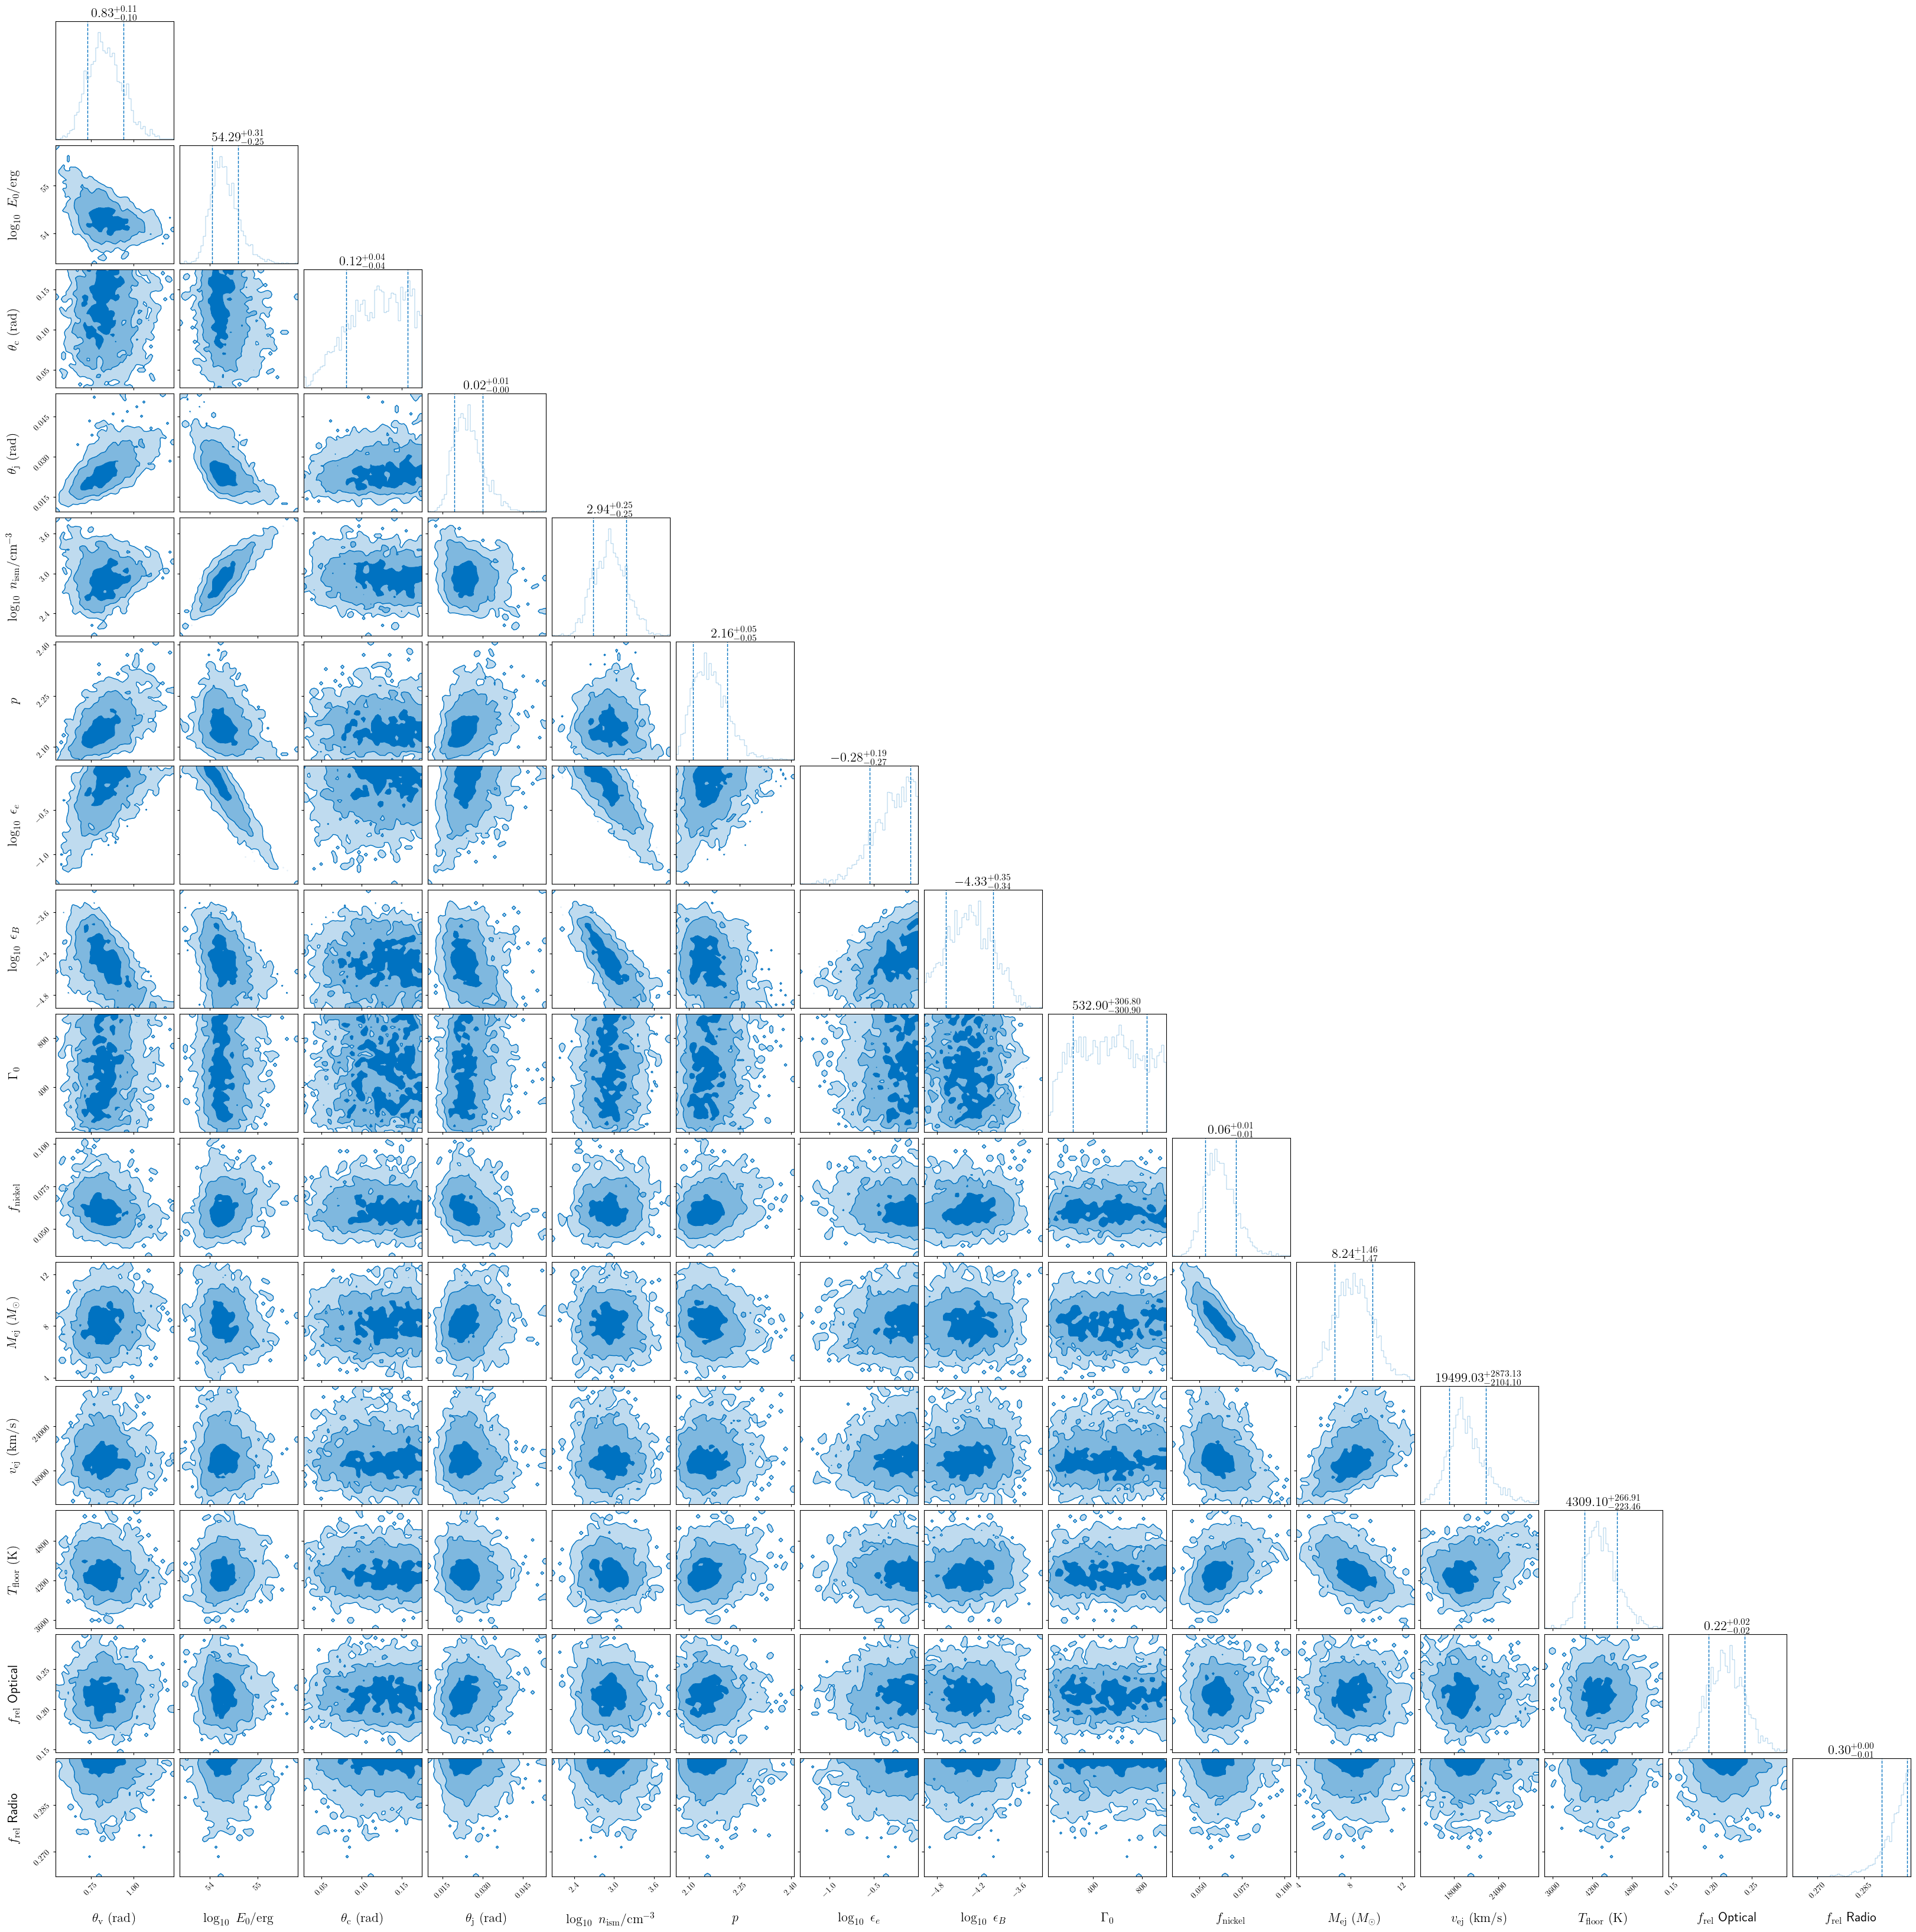

In [ ]:
#Defining the prior distributions assuming that initially all combinations are equally likely:
priorsAFTSNRADNEWLIKE = rd.priors.get_priors(model='gaussian_redback')
priorsAFTSNRADNEWLIKE.update(rd.priors.get_priors(model='arnett'))

#Modifying the gaussian afterglow priors:
priorsAFTSNRADNEWLIKE['redshift']=z
priorsAFTSNRADNEWLIKE['g0']=bb.prior.Uniform(name='g0', minimum=10, maximum=1000, latex_label='$\\Gamma_{0}$')
priorsAFTSNRADNEWLIKE['loge0']=bb.prior.Uniform(name='loge0', minimum=48, maximum=55, latex_label='$\\log_{10}~E_{0}/{\\mathrm{erg}}$')
priorsAFTSNRADNEWLIKE['logn0']=bb.prior.Uniform(name='logn0', minimum=-4, maximum=5, latex_label='$\\log_{10}~n_{\\mathrm{ism}}/{\\mathrm{cm}}^{-3}$')
priorsAFTSNRADNEWLIKE['xiN']=1
priorsAFTSNRADNEWLIKE['k']=2 #Wind-like CSM!
#priorsAFTSNRADNEWLIKE['k']=0 #ISM-like CSM!
priorsAFTSNRADNEWLIKE['thv']=bb.prior.Sine(name='thv', minimum=0, maximum=np.pi/2, latex_label='$\\theta_{\\mathrm{v}}~(\\mathrm{rad})$')
priorsAFTSNRADNEWLIKE['thc']=bb.prior.Sine(name='thc', minimum=np.deg2rad(0.09), maximum=np.deg2rad(10), latex_label='$\\theta_{\\mathrm{c}}~(\\mathrm{rad})$')
priorsAFTSNRADNEWLIKE['thj']=bb.prior.Sine(name='thj', minimum=np.deg2rad(0.09), maximum=np.deg2rad(90), latex_label='$\\theta_{\\mathrm{j}}~(\\mathrm{rad})$')
priorsAFTSNRADNEWLIKE['p']=bb.prior.Uniform(name='p', minimum=2.0, maximum=3.4, latex_label='$p$')
priorsAFTSNRADNEWLIKE['f_rel1']=bb.prior.Uniform(name='f_rel1', minimum=0.0, maximum=0.3, latex_label='$f_{\\mathrm{rel}}$ Optical')
priorsAFTSNRADNEWLIKE['f_rel2']=bb.prior.Uniform(name='f_rel2', minimum=0.0, maximum=0.3, latex_label='$f_{\\mathrm{rel}}$ Radio')

#To force epsilon_e and epsilon_b to sum up to less than 1 (physical):
def cons(parameters):
    conv_para = parameters.copy()
    conv_para['fraction'] = 10**parameters['logepse'] + 10**parameters['logepsb']
    return conv_para
priors_cons = bb.prior.PriorDict(conversion_function=cons)
for key in priorsAFTSNRADNEWLIKE:
    priors_cons[key] = priorsAFTSNRADNEWLIKE[key]
priors_cons['fraction'] = bb.prior.Constraint(minimum=0.0, maximum = 1.0) #ensures sum is <1
priorsAFTSNRADNEWLIKE = priors_cons

#Modifying the Arnett priors:
priorsAFTSNRADNEWLIKE['vej']=bb.prior.Uniform(name='vej', minimum=1000, maximum=30000, latex_label='$v_{\\mathrm{ej}}~(\\mathrm{km/s})$')
priorsAFTSNRADNEWLIKE['mej']=bb.prior.Uniform(name='mej', minimum=0.5, maximum=13, latex_label='$M_{\\mathrm{ej}}~(M_{\\odot})$')
priorsAFTSNRADNEWLIKE['kappa_gamma']=0.03
priorsAFTSNRADNEWLIKE['kappa']=0.07
priorsAFTSNRADNEWLIKE['f_nickel']=bb.prior.Uniform(name='f_nickel', minimum=0.001, maximum=0.5, latex_label='$f_{\\mathrm{nickel}}$')
priorsAFTSNRADNEWLIKE['temperature_floor']=bb.prior.Uniform(name='temperature_floor', minimum=3e3, maximum=2e4, latex_label='$T_{\\mathrm{floor}}~(\\mathrm{K})$')

#Defining the data likelihood function:
data_mode='flux_density'

likelihoodAFTSNRAD=AsymGaussianWithUpperLimits(x=OpticalTimeDaysFinal.value,y=OpticalFluxFinal.value, sigma_lower=OpticalFlux_eFinal.value, sigma_upper=OpticalFlux_EFinal.value,function=gauss_plus_arnett,detections=OpticalDetection,upper_limit_sigma=OpticalSigmaUL,data_mode='flux', unreliable_mask1=SystematicErrorMask1Final, unreliable_mask2=SystematicErrorMask2Final, kwargs = dict(
        frequency = OpticalFrequencyFinal.value,  
         output_format = "flux_density"       # ensuring flux density output
     ))


#Defining the transient (it must be a generic transsient, since we are fitting afterglow + supernova
# both at the same time), only with detections! (following REDBACK documentation comments):
name='EP240414a'

TransientAFTSNRAD=rd.transient.Transient(name=name,data_mode=data_mode,time=OpticalTimeDaysFinal.value[detection_mask],flux_density=OpticalFluxFinal.value[detection_mask],flux_density_err=np.vstack([OpticalFlux_eFinal[detection_mask].value,OpticalFlux_EFinal[detection_mask].value]),frequency=OpticalFrequencyFinal.value[detection_mask],bands=OpticalFrequencyFinal[detection_mask],active_bands=list(np.unique(OpticalFrequencyFinal.value[detection_mask])))


#Finally, fitting the model to the data:
model_kwargs = dict(frequency = OpticalFrequencyFinal,  
        output_format = "flux_density"       # ensure flux density output
    )

resultAFTSN = rd.fit_model(
    transient=TransientAFTSNRAD,
    model=gauss_plus_arnett,
    model_kwargs=model_kwargs,
    sampler="dynesty",
    likelihood=likelihoodAFTSNRAD,
    prior=priorsAFTSNRADNEWLIKE,
    nlive=300,                  # robust but not overkill
    sample="rwalk",              # good for upper limits
    npool=40,                     # using 40 cores
    queue_size=40,                # same as npool
    resume=True,
    clean=False,                 
    plot=False,
    outdir="/Fitting Folder/ Afterglow+SN Fit Combined W Afterglow Winners Constrained Priors/ Final Thesis Results",
    label="combined_fit_optical_WindGaussian"
)

resultAFTSN.plot_corner()         # corner plot showing the posterior distribution of the model parameters


# For the top-hat jet model combined with the arnett model:

In [ ]:
#Defining the priors:
priorsAFTSNRADNEWLIKE = rd.priors.get_priors(model='tophat_redback')
priorsAFTSNRADNEWLIKE.update(rd.priors.get_priors(model='arnett'))

#Modifying the tophat afterglow priors:
priorsAFTSNRADNEWLIKE['redshift']=z
priorsAFTSNRADNEWLIKE['g0']=bb.prior.Uniform(name='g0', minimum=10, maximum=2000, latex_label='$\\Gamma_{0}$')
priorsAFTSNRADNEWLIKE['loge0']=bb.prior.Uniform(name='loge0', minimum=48, maximum=55, latex_label='$\\log_{10}~E_{0}/{\\mathrm{erg}}$')
priorsAFTSNRADNEWLIKE['logn0']=bb.prior.Uniform(name='logn0', minimum=-4, maximum=5, latex_label='$\\log_{10}~n_{\\mathrm{ism}}/{\\mathrm{cm}}^{-3}$')
priorsAFTSNRADNEWLIKE['xiN']=1
priorsAFTSNRADNEWLIKE['k']=0 #ISM-like CSM!
#priorsAFTSNRADNEWLIKE['k']=2 #Wind-like CSM!
priorsAFTSNRADNEWLIKE['thv']=bb.prior.Sine(name='thv', minimum=0, maximum=np.pi/2, latex_label='$\\theta_{\\mathrm{v}}~(\\mathrm{rad})$')
priorsAFTSNRADNEWLIKE['thc']=bb.prior.Sine(name='thc', minimum=np.deg2rad(0.09), maximum=np.deg2rad(10), latex_label='$\\theta_{\\mathrm{c}}~(\\mathrm{rad})$')
priorsAFTSNRADNEWLIKE['p']=bb.prior.Uniform(name='p', minimum=2.0, maximum=3.4, latex_label='$p$')
priorsAFTSNRADNEWLIKE['f_rel1']=bb.prior.Uniform(name='f_rel1', minimum=0.0, maximum=0.3, latex_label='$f_{\\mathrm{rel}}$ Optical')
priorsAFTSNRADNEWLIKE['f_rel2']=bb.prior.Uniform(name='f_rel2', minimum=0.0, maximum=0.3, latex_label='$f_{\\mathrm{rel}}$ Radio')

#To force epse and epsb to sum up to less than 1:
def cons(parameters):
    conv_para = parameters.copy()
    conv_para['fraction'] = 10**parameters['logepse'] + 10**parameters['logepsb']
    return conv_para
priors_cons = bb.prior.PriorDict(conversion_function=cons)
for key in priorsAFTSNRADNEWLIKE:
    priors_cons[key] = priorsAFTSNRADNEWLIKE[key]
priors_cons['fraction'] = bb.prior.Constraint(minimum=0.0, maximum = 1.0) #ensures sum is <1
priorsAFTSNRADNEWLIKE = priors_cons

#Modifying the Arnett priors:
priorsAFTSNRADNEWLIKE['vej']=bb.prior.Uniform(name='vej', minimum=1000, maximum=30000, latex_label='$v_{\\mathrm{ej}}~(\\mathrm{km/s})$')
priorsAFTSNRADNEWLIKE['mej']=bb.prior.Uniform(name='mej', minimum=0.5, maximum=13, latex_label='$M_{\\mathrm{ej}}~(M_{\\odot})$')
priorsAFTSNRADNEWLIKE['kappa_gamma']=0.03 
priorsAFTSNRADNEWLIKE['kappa']=0.07 
priorsAFTSNRADNEWLIKE['f_nickel']=bb.prior.Uniform(name='f_nickel', minimum=0.00001, maximum=0.5, latex_label='$f_{\\mathrm{nickel}}$')
priorsAFTSNRADNEWLIKE['temperature_floor']=bb.prior.Uniform(name='temperature_floor', minimum=3e3, maximum=2e4, latex_label='$T_{\\mathrm{floor}}~(\\mathrm{K})$')


#Defining the data likelihood function:
data_mode='flux_density'

#Using our custom likelihood function
likelihoodAFTSNRAD=AsymGaussianWithUpperLimits(x=OpticalTimeDaysFinal.value,y=OpticalFluxFinal.value, sigma_lower=OpticalFlux_eFinal.value, sigma_upper=OpticalFlux_EFinal.value,function=tophat_plus_arnett,detections=OpticalDetection,upper_limit_sigma=OpticalSigmaUL,data_mode='flux', unreliable_mask1=SystematicErrorMask1Final, unreliable_mask2=SystematicErrorMask2Final, kwargs = dict(
        frequency = OpticalFrequencyFinal.value,   
         output_format = "flux_density"       # ensure flux density output
     ))


#Defining the transient (it must be a generic transient, since we are fitting afterglow + supernova
# both at the same time), only with detections! following redback tutorial:
name='EP240414a'

TransientAFTSNRAD=rd.transient.Transient(name=name,data_mode=data_mode,time=OpticalTimeDaysFinal.value[detection_mask],flux_density=OpticalFluxFinal.value[detection_mask],flux_density_err=np.vstack([OpticalFlux_eFinal[detection_mask].value,OpticalFlux_EFinal[detection_mask].value]),frequency=OpticalFrequencyFinal.value[detection_mask],bands=OpticalFrequencyFinal.value[detection_mask],active_bands=list(np.unique(OpticalFrequencyFinal.value[detection_mask])))


#Finally, fitting our model to the data:
model_kwargs = dict(frequency = OpticalFrequencyFinal.value,  
        output_format = "flux_density"       # ensure flux density output
    )

resultAFTSN = rd.fit_model(
    transient=TransientAFTSNRAD,
    model=tophat_plus_arnett,
    model_kwargs=model_kwargs,
    sampler="dynesty",
    likelihood=likelihoodAFTSNRAD,
    prior=priorsAFTSNRADNEWLIKE,
    nlive=300,                  # robust but not overkill
    sample="rwalk",              # good for upper limits
    npool=40,                     # use 40 cores
    queue_size=40,                # same as npool
    resume=True,
    clean=False,                 
    plot=False,
    outdir="/Fitting Folder/ Afterglow+SN Fit Combined W Afterglow Winners Constrained Priors/ Final Thesis Results",
    label="combined_fit_optical_Tophat"
)

resultAFTSN.plot_corner()         # corner plot of posterior distribution of model parameters


16:28 redback INFO    : Likelihood provided, using custom likelihood AsymGaussianWithUpperLimits
16:28 redback INFO    : Loading result from file: /data/egonzalezramos/Fitting Folder/ Afterglow+SN Fit Combined W Afterglow Winners Constrained Priors/ Final Thesis Results/combined_fit_optical_Tophat_result.json
16:28 redback INFO    : Successfully loaded result for 'combined_fit_optical_Tophat' (model: tophat_plus_arnett)


nsamples: 2158
ln_noise_evidence: -23299.202
ln_evidence: 439.554 +/-  0.382
ln_bayes_factor: 23738.756 +/-  0.382

